# Monetary IRFs from US Data

This code imports FRED data for monetary policy IRFs with US data and then analyzes IRFs for a monetary policy shock using VAR, LP, and SLP. The variables used are the [federal funds effective rate](https://fred.stlouisfed.org/series/DFF#), [real GDP](https://fred.stlouisfed.org/series/GDPC1), and [personal consumption expenditures](https://fred.stlouisfed.org/series/DPCCRV1Q225SBEA). Data is from Jan 2012 - Oct 2025.

In [23]:
# append the path of the parent directory to import slp modules
import sys
sys.path.append("..")

# import packages
import statsmodels as sm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.api import VAR

# import slp modules
from slp.estimators import SmoothLocalProjections
from slp.results import LPResults, SLPResults

In [24]:
# set parameters
q = 12 # number of quarters for IRFs

### Loading, processing, and visualizing data

In [25]:
# load data
gdp = pd.read_csv('../example_notebooks/monetary_example_data/GDPC1.csv', index_col=0, parse_dates=True)
pce = pd.read_csv('../example_notebooks/monetary_example_data/DPCCRV1Q225SBEA.csv', index_col=0, parse_dates=True)
ffr = pd.read_csv('../example_notebooks/monetary_example_data/DFF.csv', index_col=0, parse_dates=True)

# merge data into one dataframe
data = pd.concat([gdp, pce, ffr], axis=1)
data.columns = ['GDP','Inflation', 'FFR']

# GDP growth rate
data['GDP'] = data['GDP'].pct_change() * 100
data = data.dropna() # removes first observations (missing differences)

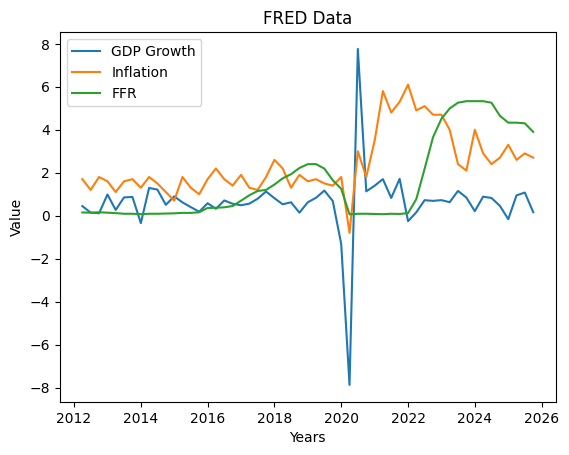

In [26]:
plt.plot(data)
plt.title("FRED Data")
plt.xlabel("Years")
plt.ylabel("Value")
plt.legend(["GDP Growth", "Inflation", "FFR"])
plt.show()

### Estimating IRFs using VAR

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


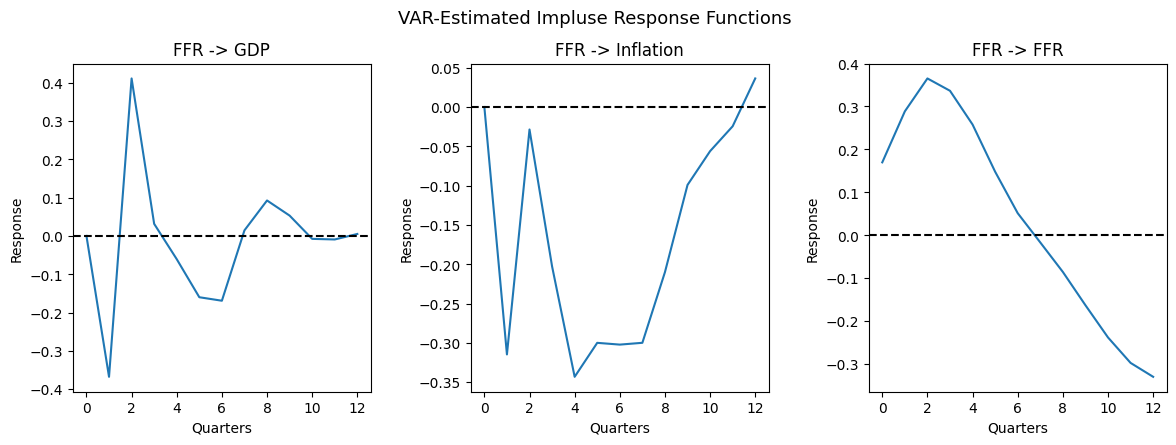

In [27]:
# VAR estimation of IRFs
model = VAR(data)
results = model.fit(ic="aic")
irf = results.irf(periods=q)
irfs = irf.orth_irfs
var_names = results.names

# plot the VAR estimated IRFs to a shock to Federal Funds Rate
plt.figure(figsize=(12, 8))
for i in range(3):
    plt.subplot(2, 3, i+1)
    plt.plot(irfs[:, i, 2])
    plt.title(f'FFR -> {var_names[i]}')
    plt.xlabel('Quarters')
    plt.ylabel('Response')
    plt.axhline(0, color='black', linestyle='dashed')
plt.suptitle('VAR-Estimated Impluse Response Functions', fontsize=13)
plt.tight_layout()
plt.show()

### Estimating IRFs using local projections

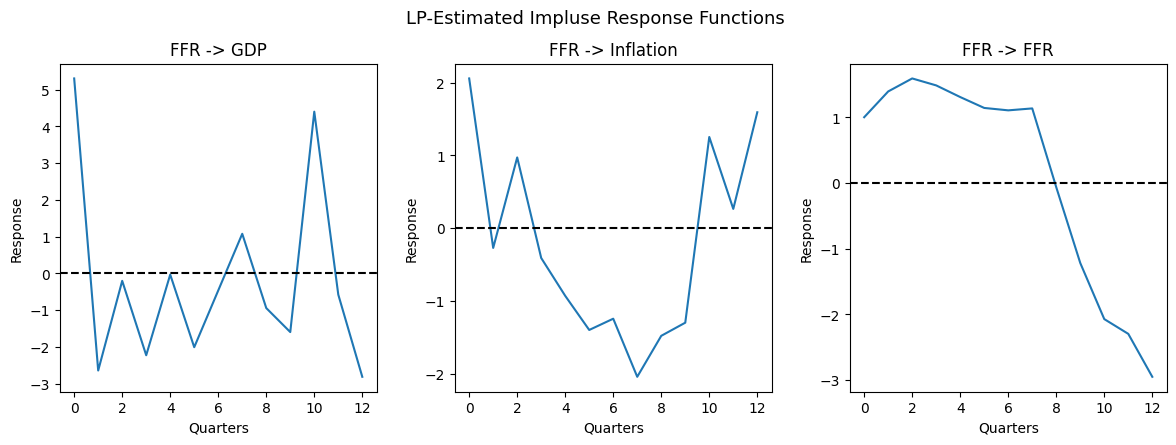

In [28]:
# LP estimation of IRFs
LP_model = SmoothLocalProjections(data, "FFR", None, True, 8, q)
LP = pd.DataFrame(LP_model.LP().beta)
LP.rename(columns={0: 'GDP', 1: 'Inflation', 2: 'FFR'}, inplace=True)
varnames = LP.columns

plt.figure(figsize=(12, 8))
for i in range(3):
    plt.subplot(2, 3, i+1)
    plt.plot(LP[varnames[i]])
    plt.title(f'FFR -> {var_names[i]}')
    plt.xlabel('Quarters')
    plt.ylabel('Response')
    plt.axhline(0, color='black', linestyle='dashed')
plt.suptitle('LP-Estimated Impluse Response Functions', fontsize=13)
plt.tight_layout()
plt.show()

### Estimating IRFs using smooth local projections

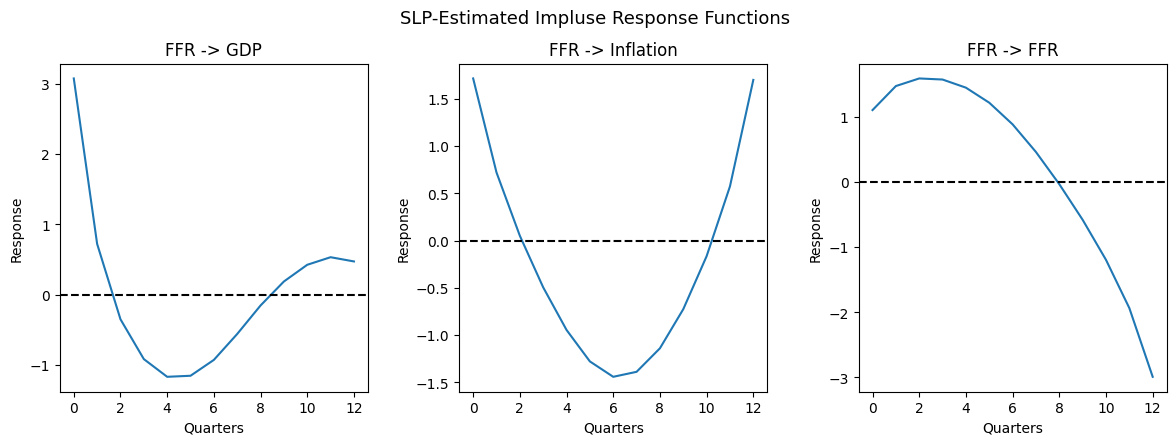

In [30]:
# SLP estimation of IRFs
SLP_model = SmoothLocalProjections(data, "FFR", None, True, 8, q)
SLP = pd.DataFrame(SLP_model.SLP().beta)
SLP.rename(columns={0: 'GDP', 1: 'Inflation', 2: 'FFR'}, inplace=True)
varnames = SLP.columns

plt.figure(figsize=(12, 8))
for i in range(3):
    plt.subplot(2, 3, i+1)
    plt.plot(SLP[varnames[i]])
    plt.title(f'FFR -> {var_names[i]}')
    plt.xlabel('Quarters')
    plt.ylabel('Response')
    plt.axhline(0, color='black', linestyle='dashed')
plt.suptitle('SLP-Estimated Impluse Response Functions', fontsize=13)
plt.tight_layout()
plt.show()

### Citations
Board of Governors of the Federal Reserve System (US), Federal Funds Effective Rate [DFF], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/DFF, April 4, 2026.
U.S. Bureau of Economic Analysis, Personal Consumption Expenditures (PCE) Excluding Food and Energy (Chain-Type Price Index) [DPCCRV1Q225SBEA], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/DPCCRV1Q225SBEA, April 4, 2026.
U.S. Bureau of Economic Analysis, Real Gross Domestic Product [GDPC1], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/GDPC1, April 4, 2026.
U.S. Bureau of Labor Statistics, Unemployment Rate [UNRATE], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/UNRATE, April 4, 2026.